# BigBasket Category Performance Diagnostic — Part 4

This notebook independently cleans `orders_raw.csv`, analyzes Delivered revenue, and cross-validates the top category and supplier against Part 1.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('orders_raw.csv')
products = pd.read_csv('products.csv')
print('orders_raw shape:', df.shape)
print('products shape:', products.shape)
df.info()
print('\nDescribe:')
print(df.describe(include='all').transpose())
print('\nStatus counts:')
print(df['status'].value_counts())

orders_raw shape: (508, 11)
products shape: (31, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB

Describe:
               count unique                   top  ...    50%     75%     max
order_id       508.0    NaN                   NaN  ...  249.5  376.25   500.0
order_date       508    165            20

## Initial data-quality observations

The raw export has 508 rows rather than the expected 500 because eight order IDs were duplicated. City and category contain deliberate casing/whitespace variations. `amount_inr` has 10 missing values (read by Pandas as `NaN`) and there are suspiciously large revenue values. Rating nulls are expected for Cancelled and Pending orders and are not treated as a data-quality defect.

In [2]:
print('Duplicate order_id rows:', df.duplicated('order_id').sum())
print('Missing amount_inr:', df['amount_inr'].isna().sum())
print('Suspicious max amount_inr:', pd.to_numeric(df['amount_inr'], errors='coerce').max())

Duplicate order_id rows: 8
Missing amount_inr: 10
Suspicious max amount_inr: 7600.0


In [3]:
df = df.drop_duplicates(subset='order_id', keep='first').copy()
print('Rows after duplicate removal:', len(df))

Rows after duplicate removal: 500


In [4]:
df['city'] = df['city'].astype(str).str.strip().str.title()
df['category'] = df['category'].astype(str).str.strip().str.title()
print('Distinct cities:', sorted(df['city'].unique().tolist()))
print('Distinct categories:', sorted(df['category'].unique().tolist()))

Distinct cities: ['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']
Distinct categories: ['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']


## Missing-value business logic

`amount_inr` has 10 missing rows. These rows are excluded from every revenue calculation because an unknown revenue amount is not the same as zero. `rating` remains null for Cancelled and Pending orders because those statuses do not receive ratings in the source-generation logic.

In [5]:
df['amount_inr'] = pd.to_numeric(df['amount_inr'], errors='coerce')
print('Missing amount_inr after numeric conversion:', df['amount_inr'].isna().sum())
print('Null ratings by status:')
print(df.groupby('status')['rating'].apply(lambda s: s.isna().sum()))

Missing amount_inr after numeric conversion: 10
Null ratings by status:
status
Cancelled    42
Delivered     0
Pending      24
Name: rating, dtype: int64


## IQR outlier detection and capping

In [6]:
delivered_amounts = df.loc[(df['status'] == 'Delivered') & df['amount_inr'].notna(), 'amount_inr']
q1 = delivered_amounts.quantile(0.25)
q3 = delivered_amounts.quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'IQR: {iqr}')
print(f'Upper fence: {upper_fence}')
print('Rows above upper fence:', (delivered_amounts > upper_fence).sum())
df['amount_inr_capped'] = df['amount_inr'].clip(upper=upper_fence)
print('Rows actually capped:', ((df['amount_inr'] > upper_fence) & (df['status'] == 'Delivered')).sum())

Q1: 90.0
Q3: 275.0
IQR: 185.0
Upper fence: 552.5
Rows above upper fence: 16
Rows actually capped: 16


In [7]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()
df['revenue_per_unit'] = df['amount_inr_capped'] / df['quantity']
df['is_delivered'] = df['status'].eq('Delivered')
print(df[['order_date','month','month_name','revenue_per_unit','is_delivered']].head())

  order_date  month month_name  revenue_per_unit  is_delivered
0 2026-03-09      3      March              35.0          True
1 2026-05-22      5        May              60.0          True
2 2026-06-30      6       June              75.0          True
3 2026-03-01      3      March              30.0          True
4 2026-04-05      4      April             110.0          True


## Category revenue

In [8]:
revenue_base = df.loc[df['is_delivered'] & df['amount_inr_capped'].notna()].copy()
category_revenue = (revenue_base.groupby('category', as_index=False)['amount_inr_capped']
                    .sum().rename(columns={'amount_inr_capped':'total_revenue'})
                    .sort_values('total_revenue', ascending=False))
print(category_revenue)
top_category = category_revenue.iloc[0]['category']
print('Top category by revenue:', top_category)

               category  total_revenue
3  Household Essentials        20910.0
0                Bakery        14975.0
4         Personal Care        14594.5
1          Dairy & Eggs        13675.0
5    Snacks & Beverages        11312.5
2   Fruits & Vegetables         9170.0
Top category by revenue: Household Essentials


## Supplier revenue via merge

In [9]:
merged = df.merge(products[['product_id','supplier']], on='product_id', how='left', validate='many_to_one')
supplier_revenue = (merged.loc[merged['is_delivered'] & merged['amount_inr_capped'].notna()]
                    .groupby('supplier', as_index=False)['amount_inr_capped']
                    .sum().rename(columns={'amount_inr_capped':'total_revenue'})
                    .sort_values('total_revenue', ascending=False))
print(supplier_revenue)
top_supplier = supplier_revenue.iloc[0]['supplier']
print('Top supplier by revenue:', top_supplier)

                 supplier  total_revenue
6  HomeEssentials Traders        20910.0
0      BakeHouse Supplies        18550.0
1   CarePlus Distributors        14594.5
3           DairyBest Ltd        10710.0
7          SnackHub India         7737.5
4           FreshFarms Co         5490.0
5     GreenValley Traders         3680.0
2       CountryEggs Farms         2965.0
Top supplier by revenue: HomeEssentials Traders


## Cross-validation against Part 1

Part 1 clean SQL found **Household Essentials** as the top category and **HomeEssentials Traders** as the dominant supplier. The independently cleaned Pandas results should match those two business facts even though the rupee totals differ because Part 4 caps IQR outliers and excludes missing revenue rows.

In [10]:
assert top_category == 'Household Essentials'
assert top_supplier == 'HomeEssentials Traders'
print('Top category matches Part 1:', top_category == 'Household Essentials')
print('Top supplier matches Part 1:', top_supplier == 'HomeEssentials Traders')

Top category matches Part 1: True
Top supplier matches Part 1: True


## Visualizations

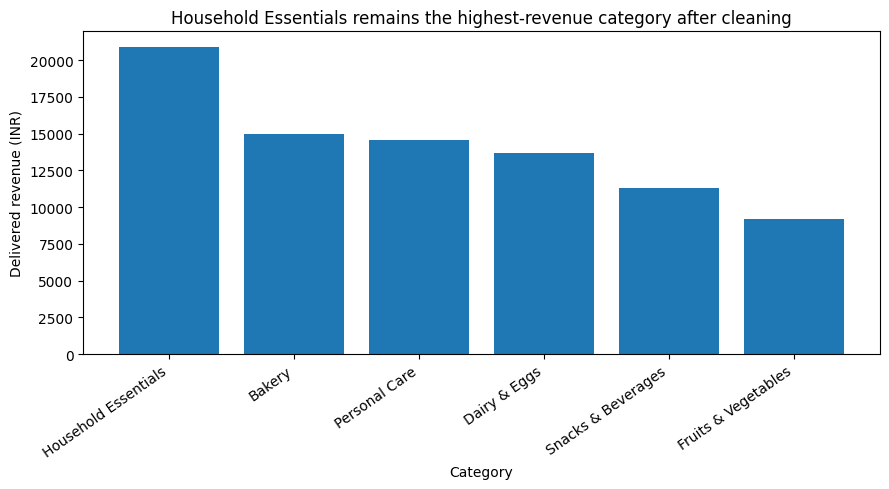

In [11]:
plt.figure(figsize=(9,5))
plt.bar(category_revenue['category'], category_revenue['total_revenue'])
plt.title('Household Essentials remains the highest-revenue category after cleaning')
plt.xlabel('Category')
plt.ylabel('Delivered revenue (INR)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

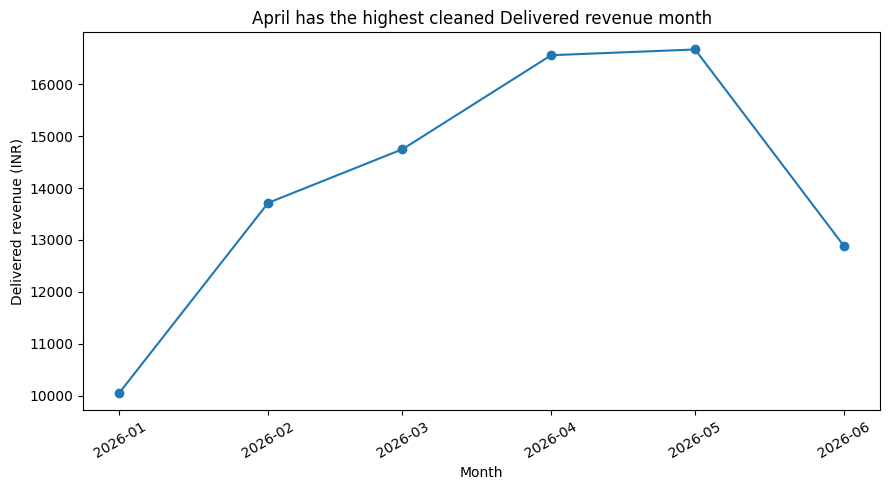

In [12]:
monthly_revenue = (revenue_base.groupby('order_date', as_index=False)['amount_inr_capped'].sum()
                  .set_index('order_date').resample('MS')['amount_inr_capped'].sum().reset_index())
plt.figure(figsize=(9,5))
plt.plot(monthly_revenue['order_date'], monthly_revenue['amount_inr_capped'], marker='o')
plt.title('April has the highest cleaned Delivered revenue month')
plt.xlabel('Month')
plt.ylabel('Delivered revenue (INR)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

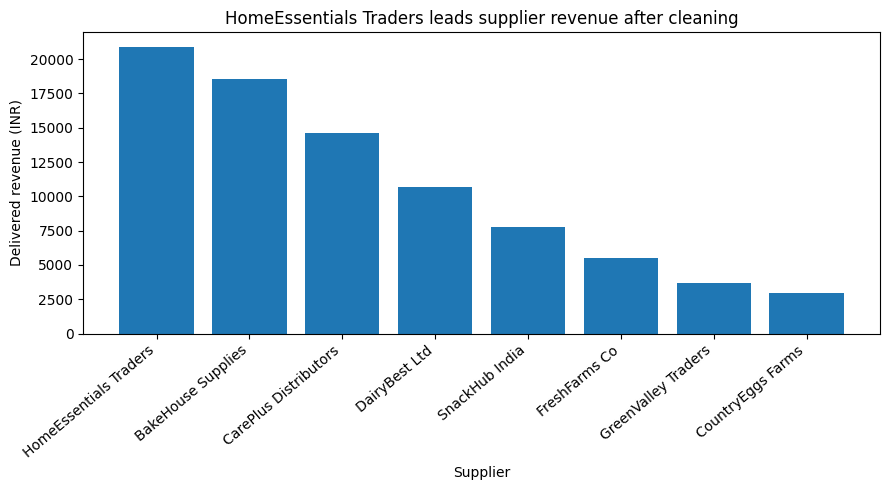

In [13]:
plt.figure(figsize=(9,5))
plt.bar(supplier_revenue['supplier'], supplier_revenue['total_revenue'])
plt.title('HomeEssentials Traders leads supplier revenue after cleaning')
plt.xlabel('Supplier')
plt.ylabel('Delivered revenue (INR)')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

## Exactly 3 business observations

### 1. What / Why it matters / Next step
**What:** Household Essentials is the top cleaned category at INR 20,910, ahead of Bakery at INR 14,975 by INR 5,935.

**Why it matters:** It is the strongest revenue contributor in the cleaned dataset and therefore has the largest revenue base to protect and grow.

**Next step:** Prioritize Household Essentials for the next category review and identify which products within that category sustain the lead.

### 2. What / Why it matters / Next step
**What:** April is the strongest cleaned month at INR 16,558.50, while January is the weakest at INR 10,059.50.

**Why it matters:** The INR 6,499.00 monthly gap shows that revenue performance varies materially across the six-month period.

**Next step:** Compare April's category mix with January's and test which categories explain the uplift before repeating the April pattern.

### 3. What / Why it matters / Next step
**What:** HomeEssentials Traders is the top supplier at INR 20,910, matching the top category's cleaned revenue because its products cover Household Essentials.

**Why it matters:** Supplier concentration makes HomeEssentials Traders a key contributor to the strongest category's performance.

**Next step:** Review this supplier's product-level revenue and availability metrics before making any category-level expansion decision.